# Pretraining on Unlabeled Data

* Based on: https://github.com/rasbt/LLMs-from-scratch/tree/main

- In this chapter, we implement the training loop and code for basic model evaluation to pretrain an LLM
- At the end of this chapter, we also load openly available pretrained weights from OpenAI into our model

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/01.webp" width=800px>

- The topics covered in this chapter are shown below

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/02.webp" width=800px>

&nbsp;
## 5.1 Evaluating generative text models

- We start this section with a brief recap of initializing a GPT model using the code from the previous chapter
- Then, we discuss basic evaluation metrics for LLMs
- Lastly, in this section, we apply these evaluation metrics to a training and validation dataset

&nbsp;
### 5.1.1 Using GPT to generate text

- We initialize a GPT model using the code from the previous chapter

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import tiktoken

import numpy as np

# ----------------------------------------------------------
GPT_CONFIG_124M = {
    "vocab_size": 50257,  # Vocabulary size
    "context_length": 256,  # Shortened context length (orig: 1024)
    "emb_dim": 768,  # Embedding dimension
    "n_heads": 12,  # Number of attention heads
    "n_layers": 12,  # Number of layers
    "drop_rate": 0.1,  # Dropout rate
    "qkv_bias": False,  # Query-key-value bias
}
# ----------------------------------------------------------


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return (
            0.5
            * x
            * (
                1
                + torch.tanh(
                    torch.sqrt(torch.tensor(2.0 / torch.pi))
                    * (x + 0.044715 * torch.pow(x, 3))
                )
            )
        )


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = (
            d_out // num_heads
        )  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_out_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_out_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_out_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, context_window, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert (
            len(token_ids) > max_length
        ), "Number of tokenized inputs must at least be equal to max_length+1"

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(
    txt,
    batch_size=4,
    max_length=256,
    stride=128,
    shuffle=True,
    drop_last=True,
    num_workers=0,
):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )

    return dataloader


torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()
# Disable dropout during inference

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_out_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feat

- We use dropout of 0.1 above, but it's relatively common to train LLMs without dropout nowadays
- Modern LLMs also don't use bias vectors in the `nn.Linear` layers for the query, key, and value matrices (unlike earlier GPT models), which is achieved by setting `"qkv_bias": False`
- We reduce the context length (`context_length`) of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens
  - This is so that more readers will be able to follow and execute the code examples on their laptop computer
  - However, please feel free to increase the `context_length` to 1024 tokens (this would not require any code changes)
  - We will also load a model with a 1024 `context_length` later from pretrained weights

- Next, we use the `generate_text_simple` function from the previous chapter to generate text
- In addition, we define two convenience functions, `text_to_token_ids` and `token_ids_to_text`, for converting between token and text representations that we use throughout this chapter

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/03.webp" width=800px>

In [4]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())


start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"],
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


&nbsp;
### 5.1.2 Calculating the text generation loss: cross-entropy and perplexity

- PyTorch already implements a `cross_entropy` function that carries out the previous steps

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/07.webp" width=600px>

- Before we apply the `cross_entropy` function, let's check the shape of the logits and targets

- For the `cross_entropy` function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

- Note that the targets are the token IDs, which also represent the index positions in the logits tensors that we want to maximize
- The `cross_entropy` function in PyTorch will automatically take care of applying the softmax and log-probability computation internally over those token indices in the logits that are to be maximized 

- A concept related to the cross-entropy loss is the perplexity of an LLM
- The perplexity is simply the exponential of the cross-entropy loss

In [5]:
torch.tensor(10.79)
torch.exp(torch.tensor(10.79))

tensor(48533.0352)

- The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens)
- In other words, perplexity provides a measure of how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset
- Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution

&nbsp;
### 5.1.3 Calculating the training and validation set losses

- We use a relatively small dataset for training the LLM (in fact, only one short story)
- The reasons are:
  - You can run the code examples in a few minutes on a laptop computer without a suitable GPU
  - The training finishes relatively fast (minutes instead of weeks), which is good for educational purposes
  - We use a text from the public domain, which can be included in this GitHub repository without violating any usage rights or bloating the repository size


- For example, Llama 2 7B required 184,320 GPU hours on A100 GPUs to be trained on 2 trillion tokens
  - At the time of this writing, the hourly cost of an 8xA100 cloud server at AWS is approximately \\$30
  - So, via an off-the-envelope calculation, training this LLM would cost 184,320 / 8 * \\$30 =  \\$690,000
 
- Below, we use the same dataset we used in chapter 2

In [6]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

- A quick check that the text loaded ok by printing the first and last 99 characters

In [7]:
# First 99 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [8]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


- With 5,145 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later)

- Next, we divide the dataset into a training and a validation set and use the data loaders from chapter 2 to prepare the batches for LLM training
- For visualization purposes, the figure below assumes a `max_length=6`, but for the training loader, we set the `max_length` equal to the context length that the LLM supports
- The figure below only shows the input tokens for simplicity
    - Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/09.webp" width=1000px>

In [9]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

In [10]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print(
        "Not enough tokens for the training loader. "
        "Try to lower the `GPT_CONFIG_124M['context_length']` or "
        "increase the `training_ratio`"
    )

if total_tokens * (1 - train_ratio) < GPT_CONFIG_124M["context_length"]:
    print(
        "Not enough tokens for the validation loader. "
        "Try to lower the `GPT_CONFIG_124M['context_length']` or "
        "decrease the `training_ratio`"
    )

- We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with
- Llama 2 7B was trained with a batch size of 1024, for example

- An optional check that the data was loaded correctly:

In [11]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- Another optional check that the token sizes are in the expected ballpark:

In [12]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- Next, we implement a utility function to calculate the cross-entropy loss of a given batch
- In addition, we implement a second utility function to compute the loss for a user-specified number of batches in a data loader

In [13]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code
- Via the `device` setting, we ensure that the data is loaded onto the same device as the LLM model

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


model.to(
    device
)  # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123)  # For reproducibility due to the shuffling in the data loader

with (
    torch.no_grad()
):  # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cuda device.
Training loss: 10.987583266364204
Validation loss: 10.98110580444336


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/10.webp" width=700px>

&nbsp;
## 5.2 Training an LLM

- In this section, we finally implement the code for training the LLM
- We focus on a simple training function (if you are interested in augmenting this training function with more advanced techniques, such as learning rate warmup, cosine annealing, and gradient clipping, please refer to [Appendix D](../../appendix-D/01_main-chapter-code))

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/11.webp" width=600px>

In [14]:
def train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer,
):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()  # Calculate loss gradients
            optimizer.step()  # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}"
                )

        # Print a sample text after each epoch
        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded, max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

- Now, let's train the LLM using the training function defined above:

In [20]:
# Note:
# Uncomment the following code to calculate the execution time
# import time
# start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.1)

num_epochs = 10

In [ ]:
train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer,
)

# Note:
# Uncomment the following code to show the execution time
# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 10.535, Val loss 10.574
Ep 1 (Step 000005): Train loss 9.200, Val loss 9.416
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000010): Train loss 8.621, Val loss 8.884
Ep 2 (Step 000015): Train loss 8.143, Val loss 8.421
Every effort moves you, the, the the the the the the the the the the the.                                   
Ep 3 (Step 000020): Train loss 7.650, Val loss 7.986
Ep 3 (Step 000025): Train loss 7.140, Val loss 7.591
Every effort moves you, the, the, the, the, the, the, the.                                   
Ep 4 (Step 000030): Train loss 6.691, Val loss 7.262
Ep 4 (Step 000035): Train loss 6.341, Val loss 6.986
Every effort moves you, and, and the the the the the the, and the.                                    
Ep 5 (Step 000040): Train loss 5.820, Val loss 6.817
Every effort moves you, and I had the   "-- the     ", I had the of the   "I. "I the the  "-- the "I, and I had the "I
Ep 6 (Step 000045): Tra

In [15]:
torch.exp(torch.tensor(6.133))

tensor(460.8165)

- Note that you might get slightly different loss values on your computer, which is not a reason for concern if they are roughly similar (a training loss below 1 and a validation loss below 7)
- Small differences can often be due to different GPU hardware and CUDA versions or small changes in newer PyTorch versions
- Even if you are running the example on a CPU, you may observe slight differences; a possible reason for a discrepancy is the differing behavior of `nn.Dropout` across operating systems, depending on how PyTorch was compiled, as discussed [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

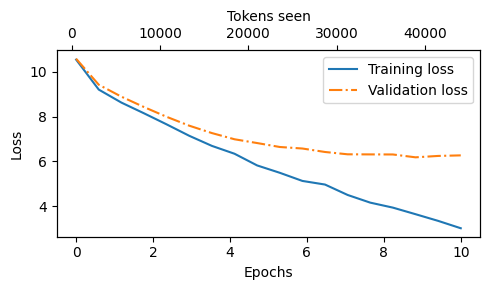

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(
        MaxNLocator(integer=True)
    )  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.show()


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- Looking at the results above, we can see that the model starts out generating incomprehensible strings of words, whereas towards the end, it's able to produce grammatically more or less correct sentences
- However, based on the training and validation set losses, we can see that the model starts overfitting
- If we were to check a few passages it writes towards the end, we would find that they are contained in the training set verbatim -- it simply memorizes the training data
- Later, we will cover decoding strategies that can mitigate this memorization by a certain degree
- Note that the overfitting here occurs because we have a very, very small training set, and we iterate over it so many times
  - The LLM training here primarily serves educational purposes; we mainly want to see that the model can learn to produce coherent text
  - Instead of spending weeks or months on training this model on vast amounts of expensive hardware, we load pretrained weights later

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/13.webp" width=700px>

&nbsp;
## 5.3 Decoding strategies to control randomness

- Inference is relatively cheap with a relatively small LLM as the GPT model we trained above, so there's no need to use a GPU for it in case you used a GPU for training it above
- Using the `generate_text_simple` function (from the previous chapter) that we used earlier inside the simple training function, we can generate new text one word (or token) at a time
- As explained in section 5.1.2, the next generated token is the token corresponding to the largest probability score among all tokens in the vocabulary

In [ ]:
# NEW: use CPU here as inference is cheap with
# this model and to ensure readers get same results in the
# remaining sections of this book
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"],
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know it was not that the picture.




"I had the---and I felt to me,


- Even if we execute the `generate_text_simple` function above multiple times, the LLM will always generate the same outputs
- We now introduce two concepts, so-called decoding strategies, to modify the `generate_text_simple`: *temperature scaling* and *top-k* sampling
- These will allow the model to control the randomness and diversity of the generated text

&nbsp;
### 5.3.1 Temperature scaling

- Previously, we always sampled the token with the highest probability as the next token using `torch.argmax`
- To add variety, we can sample the next token using The `torch.multinomial(probs, num_samples=1)`, sampling from a probability distribution
- Here, each index's chance of being picked corresponds to its probability in the input tensor

- Here's a little recap of generating the next token, assuming a very small vocabulary for illustration purposes:

In [ ]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

# The next generated token is then as follows:
print(inverse_vocab[next_token_id])

forward


In [19]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


- Instead of determining the most likely token via `torch.argmax`, we use `torch.multinomial(probas, num_samples=1)` to determine the most likely token by sampling from the softmax distribution
- For illustration purposes, let's see what happens when we sample the next token 1,000 times using the original softmax probabilities:

In [ ]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)  # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")


print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


- We can control the distribution and selection process via a concept called temperature scaling
- "Temperature scaling" is just a fancy word for dividing the logits by a number greater than 0
- Temperatures greater than 1 will result in more uniformly distributed token probabilities after applying the softmax
- Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions after applying the softmax

- Note that the resulting dropout outputs may look different depending on your operating system; you can read more about this inconsistency [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

In [ ]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)


# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

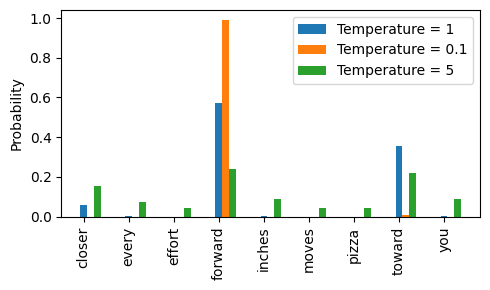

In [ ]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(
        x + i * bar_width, scaled_probas[i], bar_width, label=f"Temperature = {T}"
    )

ax.set_ylabel("Probability")
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- We can see that the rescaling via temperature 0.1 results in a sharper distribution, approaching `torch.argmax`, such that the most likely word is almost always selected:

In [23]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


- The rescaled probabilities via temperature 5 are more uniformly distributed:

In [24]:
print_sampled_tokens(scaled_probas[2])

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


- Assuming an LLM input "every effort moves you", using the approach above can sometimes result in nonsensical texts, such as "every effort moves you pizza", 3.2% of the time (32 out of 1000 times)

&nbsp;
### 5.3.3 Modifying the text generation function

- The previous two subsections introduced temperature sampling and top-k sampling
- Let's use these two concepts to modify the `generate_text_simple` function from chapter 4, creating a new `generate` function:

In [15]:
def generate(
    model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None
):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits
            )

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if (
            idx_next == eos_id
        ):  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [ ]:
# torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4,
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you--only with a a good to for--
_

He of


&nbsp;
## 5.4 Loading and saving model weights in PyTorch

- Training LLMs is computationally expensive, so it's crucial to be able to save and load LLM weights

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/16.webp" width=600px>

- The recommended way in PyTorch is to save the model weights, the so-called `state_dict` via by applying the `torch.save` function to the `.state_dict()` method:

In [27]:
torch.save(model.state_dict(), "model.pth")

- Then we can load the model weights into a new `GPTModel` model instance as follows:

In [ ]:
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval()

Device: cuda


- It's common to train LLMs with adaptive optimizers like Adam or AdamW instead of regular SGD
- These adaptive optimizers store additional parameters for each model weight, so it makes sense to save them as well in case we plan to continue the pretraining later:

In [ ]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth",
)

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train()

&nbsp;
## 5.5 Loading pretrained weights from OpenAI

- Previously, we only trained a small GPT-2 model using a very small short-story book for educational purposes
- Interested readers can also find a longer pretraining run on the complete Project Gutenberg book corpus in [../03_bonus_pretraining_on_gutenberg](../03_bonus_pretraining_on_gutenberg)
- Fortunately, we don't have to spend tens to hundreds of thousands of dollars to pretrain the model on a large pretraining corpus but can load the pretrained weights provided by OpenAI

In [16]:
import urllib

file_name = "gpt2-small-124M.pth"
# file_name = "gpt2-medium-355M.pth"
# file_name = "gpt2-large-774M.pth"
# file_name = "gpt2-xl-1558M.pth"

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)
    print(f"Downloaded to {file_name}")

BASE_CONFIG = {
    "vocab_size": 50257,  # Vocabulary size
    "context_length": 1024,  # Shortened context length (orig: 1024)
    "emb_dim": 768,  # Embedding dimension
    "n_heads": 12,  # Number of attention heads
    "n_layers": 12,  # Number of layers
    "drop_rate": 0.1,  # Dropout rate
    "qkv_bias": True,  # Query-key-value bias
}

NEW_CONFIG = {
    "vocab_size": 50257,  # Vocabulary size
    "context_length": 256,  # Shortened context length (orig: 1024)
    "emb_dim": 768,  # Embedding dimension
    "n_heads": 12,  # Number of attention heads
    "n_layers": 12,  # Number of layers
    "drop_rate": 0.1,  # Dropout rate
    "qkv_bias": True,  # Query-key-value bias
}


gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=True))
gpt.eval()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")
gpt.to(device)


torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Hello", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5,
)
gpt.eval()
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Hello as usual the update can use some useful syntax rules that add data values. This lets you perform your own checks before you add


In [17]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_out_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_featur

In [18]:
gpt.to(device)
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("The meaning of life is", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5,
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 The meaning of life is SavSTONdirtymanufact Jordanarlane attacked unfortunate Historic Evangel Rein salute Liquidarak wraps sunscreenogluDIS Logo Keeper calculatorincludeRequired vividly Kinn


# Fully re-train gpt-2

In [ ]:
print(
    "optimizer params:",
    sum(p.numel() for g in optimizer.param_groups for p in g["params"]),
)
print("trainable params:", sum(p.numel() for p in gpt.parameters() if p.requires_grad))

optimizer params: 163037184
trainable params: 163037184


In [ ]:
torch.manual_seed(123)

optimizer = torch.optim.AdamW(gpt.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    gpt,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=num_epochs,
    eval_freq=5,
    eval_iter=5,
    start_context="The meaning of life is",
    tokenizer=tokenizer,
)

Ep 1 (Step 000000): Train loss 4.982, Val loss 6.700
Ep 1 (Step 000005): Train loss 4.712, Val loss 6.554
The meaning of life is the, and I had a of the to the--I.  "I--I, and I had been the. "I, and I had been.    "I, and I had been, and I had
Ep 2 (Step 000010): Train loss 4.587, Val loss 6.481
Ep 2 (Step 000015): Train loss 4.284, Val loss 6.411
The meaning of life is to the, and the, and I had the--I, and I had been, and, and I had been the to, and I had been the, and I had been. "--, and--, and, and I had
Ep 3 (Step 000020): Train loss 4.202, Val loss 6.394
Ep 3 (Step 000025): Train loss 3.963, Val loss 6.331
The meaning of life is the, and in the of the to the the of the.           "I, and I, and I had been. I had been. I had been, and, and he was his pictures
Ep 4 (Step 000030): Train loss 3.830, Val loss 6.338
Ep 4 (Step 000035): Train loss 3.756, Val loss 6.287
The meaning of life is the, and in the picture.     "I a.        "I, and I, I had been his, and he was his, the, and 

# Taller en clase
* Implentar paciencia en optimizador
* Realizar ajuste fino con el libro de 1984

## Patience implementation 

In [22]:
# This is a custom local dir to store logs and checkpoints
# Since I push everything to github, this makes it easier to focus on
# the code and not to push logs and checkpoints
from settings import LOGS_DIR

In [67]:
def train_model_with_patience(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer,
    experiment_name,
    patience=3,
):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    running_patience = patience
    best_val_loss = float("inf")

    # Create checkpoints directory if it doesn't exist
    ckpts_dir = os.path.join(LOGS_DIR, "gpt-2", experiment_name, "checkpoints")
    if not os.path.exists(ckpts_dir):
        os.makedirs(ckpts_dir)

    # Main training loop
    for epoch in range(num_epochs):
        print("|", "-" * 50, f"Epoch {epoch+1}", "-" * 50, "|")
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()  # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()  # Calculate loss gradients
            optimizer.step()  # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}"
                )

        # Implement patience mechanism and best model checkpointing
        # We do this manually because val_loss is only calculated every eval_freq steps, and not after every epoch
        _, epoch_val_loss = evaluate_model(
            model, train_loader, val_loader, device, eval_iter
        )
        print(f"Validation loss = {epoch_val_loss:.3f}")
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            running_patience = patience  # Reset patience
            # Save the best model checkpoint
            torch.save(model.state_dict(), os.path.join(ckpts_dir, "best.pth"))
        else:
            running_patience -= 1  # Decrease patience if no improvement
            if running_patience == 0:
                generate_and_print_sample(model, tokenizer, device, start_context)

                print(
                    f"No improvement in validation loss for {patience} evaluations. Stopping training."
                )
                break  # Stop training if patience is exhausted

        # Print a sample text after each epoch
        generate_and_print_sample(model, tokenizer, device, start_context)

    print("|", "-" * 50, f"Results", "-" * 50, "|")
    print(f"Best validation loss: {best_val_loss:.3f}")
    best_model_ckpt = os.path.join(ckpts_dir, 'best.pth')
    print(
        f"Best model checkpoint saved at: {best_model_ckpt}"
    )

    return train_losses, val_losses, track_tokens_seen, best_model_ckpt

In [68]:
# Simple sanity check to see if the patience mechanism works
train_losses, val_losses, track_tokens_seen, best_model_ckpt = (
    train_model_with_patience(
        model=gpt,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        num_epochs=5,
        eval_freq=10,
        eval_iter=5,
        start_context="The meaning of life is",
        tokenizer=tokenizer,
        experiment_name="test_patience",
        patience=1,  # Set a low patience for testing
    )
)

| -------------------------------------------------- Epoch 1 -------------------------------------------------- |
Ep 1 (Step 000000): Train loss 3.711, Val loss 3.560
Validation loss = 3.560
The meaning of life is not the same as the meaning of death.  The meaning of life is not the same as the meaning of death.  The meaning of life is not the same as the meaning of death.  The meaning of life is not the
| -------------------------------------------------- Epoch 2 -------------------------------------------------- |
Ep 2 (Step 000010): Train loss 3.714, Val loss 3.560
Validation loss = 3.560
The meaning of life is not the same as the meaning of death.  The meaning of life is not the same as the meaning of death.  The meaning of life is not the same as the meaning of death.  The meaning of life is not the
No improvement in validation loss for 1 evaluations. Stopping training.
| -------------------------------------------------- Results -------------------------------------------------- 

## GPT-2 fine tunning over Orwell's 1984

In [91]:
BASE_CONFIG = {
    "vocab_size": 50257,  # Vocabulary size
    "context_length": 1024,  # Shortened context length (orig: 1024)
    "emb_dim": 768,  # Embedding dimension
    "n_heads": 12,  # Number of attention heads
    "n_layers": 12,  # Number of layers
    "drop_rate": 0.1,  # Dropout rate
    "qkv_bias": True,  # Query-key-value bias
}

In [92]:
file_path = "orwell-1984.txt"

with open(file_path, "r", encoding="utf-8") as file:
    orwell_1984 = file.read()

In [93]:
# First 99 characters
print(orwell_1984[:99])



Project Gutenberg Australia



Title: Nineteen eighty-four
Author: George Orwell (pseudonym of Er


In [94]:
total_characters = len(orwell_1984)
total_tokens = len(tokenizer.encode(orwell_1984))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 588097
Tokens: 141455


In [95]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(orwell_1984))
train_data = orwell_1984[:split_idx]
val_data = orwell_1984[split_idx:]
batch_size = 16

torch.manual_seed(123)

train_loader_1984 = create_dataloader_v1(
    train_data,
    batch_size=batch_size,
    max_length=BASE_CONFIG["context_length"],
    stride=BASE_CONFIG["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0,
)

val_loader_1984 = create_dataloader_v1(
    val_data,
    batch_size=batch_size,
    max_length=BASE_CONFIG["context_length"],
    stride=BASE_CONFIG["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0,
)

In [96]:
# Sanity check
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print(
        "Not enough tokens for the training loader. "
        "Try to lower the `GPT_CONFIG_124M['context_length']` or "
        "increase the `training_ratio`"
    )

if total_tokens * (1 - train_ratio) < GPT_CONFIG_124M["context_length"]:
    print(
        "Not enough tokens for the validation loader. "
        "Try to lower the `GPT_CONFIG_124M['context_length']` or "
        "decrease the `training_ratio`"
    )

- Another optional check that the token sizes are in the expected ballpark:

In [97]:
train_tokens = 0
for input_batch, target_batch in train_loader_1984:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader_1984:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 114688
Validation tokens: 13312
All tokens: 128000


In [98]:
import urllib

file_name = "gpt2-small-124M.pth"
# file_name = "gpt2-medium-355M.pth"
# file_name = "gpt2-large-774M.pth"
# file_name = "gpt2-xl-1558M.pth"

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)
    print(f"Downloaded to {file_name}")

gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=True))

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

In [99]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

gpt.to(device)
torch.manual_seed(123)
num_epochs = 10

In [103]:
# Helpers for 5D hyperparameter search (lr, wd, unfrozen layers, context length, batch size)
from itertools import product

PRETRAINED_CKPT = "gpt2-small-124M.pth"


def build_model_from_pretrained(context_length):
    cfg = BASE_CONFIG.copy()
    cfg["context_length"] = context_length

    model = GPTModel(cfg)
    state_dict = torch.load(PRETRAINED_CKPT, map_location="cpu", weights_only=True)

    # If using shorter context than pretrained 1024, slice positional embeddings.
    if state_dict["pos_emb.weight"].shape[0] != context_length:
        state_dict["pos_emb.weight"] = state_dict["pos_emb.weight"][:context_length, :]

    # Attention masks are registered buffers whose shape depends on context_length.
    # Remove them from checkpoint and let each model instance keep its own mask buffers.
    for key in list(state_dict.keys()):
        if key.endswith("att.mask"):
            del state_dict[key]

    incompatible = model.load_state_dict(state_dict, strict=False)
    unexpected = list(incompatible.unexpected_keys)
    missing = list(incompatible.missing_keys)

    if unexpected:
        raise RuntimeError(f"Unexpected keys when loading pretrained checkpoint: {unexpected}")

    non_mask_missing = [k for k in missing if not k.endswith("att.mask")]
    if non_mask_missing:
        raise RuntimeError(f"Missing non-mask keys when loading pretrained checkpoint: {non_mask_missing}")

    return model, cfg


def configure_trainable_params(model, unfreeze_mode):
    for p in model.parameters():
        p.requires_grad = False

    # Always train output head.
    model.out_head.weight.requires_grad = True

    if unfreeze_mode == "output_head_only":
        return

    if unfreeze_mode == "last2_blocks":
        # Also train final norm + last 2 transformer blocks.
        for p in model.final_norm.parameters():
            p.requires_grad = True
        for block in model.trf_blocks[-2:]:
            for p in block.parameters():
                p.requires_grad = True
        return

    raise ValueError(f"Unsupported unfreeze_mode: {unfreeze_mode}")


def build_1984_dataloaders(context_length, batch_size):
    train_loader_local = create_dataloader_v1(
        train_data,
        batch_size=batch_size,
        max_length=context_length,
        stride=context_length,
        drop_last=True,
        shuffle=True,
        num_workers=0,
    )

    val_loader_local = create_dataloader_v1(
        val_data,
        batch_size=batch_size,
        max_length=context_length,
        stride=context_length,
        drop_last=False,
        shuffle=False,
        num_workers=0,
    )

    return train_loader_local, val_loader_local

In [104]:
# Sanity check: pretrained load works for both context lengths used in the grid
for ctx in [1024, 512]:
    m, c = build_model_from_pretrained(context_length=ctx)
    print(f"OK: context_length={ctx}, pos_emb={tuple(m.pos_emb.weight.shape)}")

del m, c

OK: context_length=1024, pos_emb=(1024, 768)
OK: context_length=512, pos_emb=(512, 768)


In [101]:
# Define 5D grid: learning rate, weight decay, unfreeze strategy, context length, batch size
learning_rates = [5e-5, 5e-4]
weight_decays = [0.1, 0.01]
unfreeze_modes = ["output_head_only", "last2_blocks"]
context_lengths = [1024, 512]
batch_sizes = [16, 8]

param_grid = list(
    product(
        learning_rates,
        weight_decays,
        unfreeze_modes,
        context_lengths,
        batch_sizes,
    )
)

print(f"Total runs: {len(param_grid)}")
param_grid

Total runs: 32


[(5e-05, 0.1, 'output_head_only', 1024, 16),
 (5e-05, 0.1, 'output_head_only', 1024, 8),
 (5e-05, 0.1, 'output_head_only', 512, 16),
 (5e-05, 0.1, 'output_head_only', 512, 8),
 (5e-05, 0.1, 'last2_blocks', 1024, 16),
 (5e-05, 0.1, 'last2_blocks', 1024, 8),
 (5e-05, 0.1, 'last2_blocks', 512, 16),
 (5e-05, 0.1, 'last2_blocks', 512, 8),
 (5e-05, 0.01, 'output_head_only', 1024, 16),
 (5e-05, 0.01, 'output_head_only', 1024, 8),
 (5e-05, 0.01, 'output_head_only', 512, 16),
 (5e-05, 0.01, 'output_head_only', 512, 8),
 (5e-05, 0.01, 'last2_blocks', 1024, 16),
 (5e-05, 0.01, 'last2_blocks', 1024, 8),
 (5e-05, 0.01, 'last2_blocks', 512, 16),
 (5e-05, 0.01, 'last2_blocks', 512, 8),
 (0.0005, 0.1, 'output_head_only', 1024, 16),
 (0.0005, 0.1, 'output_head_only', 1024, 8),
 (0.0005, 0.1, 'output_head_only', 512, 16),
 (0.0005, 0.1, 'output_head_only', 512, 8),
 (0.0005, 0.1, 'last2_blocks', 1024, 16),
 (0.0005, 0.1, 'last2_blocks', 1024, 8),
 (0.0005, 0.1, 'last2_blocks', 512, 16),
 (0.0005, 0.1, '

In [105]:
results_grid = {}

for lr, wd, unfreeze_mode, context_length, batch_size in param_grid:
    print("\n" + "=" * 100)
    print(
        "Training with "
        f"lr={lr}, wd={wd}, unfreeze={unfreeze_mode}, "
        f"ctx={context_length}, bs={batch_size}"
    )

    # Rebuild dataloaders for this context length + batch size.
    train_loader_run, val_loader_run = build_1984_dataloaders(
        context_length=context_length,
        batch_size=batch_size,
    )

    # Rebuild model from the same pretrained checkpoint for fair comparisons.
    model_run, cfg_run = build_model_from_pretrained(context_length=context_length)
    configure_trainable_params(model_run, unfreeze_mode=unfreeze_mode)
    model_run.to(device)

    optimizer = torch.optim.AdamW(
        (p for p in model_run.parameters() if p.requires_grad),
        lr=lr,
        weight_decay=wd,
    )

    experiment_name = (
        f"lr_{lr}_wd_{wd}_ul_{unfreeze_mode}_ctx_{context_length}_bs_{batch_size}"
    )

    train_losses, val_losses, tokens_seen, best_model_ckpt = train_model_with_patience(
        model_run,
        train_loader_run,
        val_loader_run,
        optimizer,
        device,
        num_epochs=num_epochs,
        eval_freq=10,
        eval_iter=5,
        start_context="Freedom is the freedom to say that",
        experiment_name=experiment_name,
        tokenizer=tokenizer,
        patience=3,
    )

    key = (lr, wd, unfreeze_mode, context_length, batch_size)
    results_grid[key] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "tokens_seen": tokens_seen,
        "best_model_ckpt": best_model_ckpt,
        "best_val_loss": min(val_losses),
        "final_val_loss": val_losses[-1],
        "context_length": context_length,
        "batch_size": batch_size,
        "unfreeze_mode": unfreeze_mode,
    }

print("\nGrid search complete.")
print(f"Stored results for {len(results_grid)} runs.")


Training with lr=5e-05, wd=0.1, unfreeze=output_head_only, ctx=1024, bs=16
| -------------------------------------------------- Epoch 1 -------------------------------------------------- |
Ep 1 (Step 000000): Train loss 3.566, Val loss 3.598
Validation loss = 3.565
Freedom is the freedom to say that you're not a racist, sexist, homophobic, transphobic, or any other kind of bigot.  I'm not saying that you should be allowed to say that you're not a racist, sexist, homophobic, transphobic, or
| -------------------------------------------------- Epoch 2 -------------------------------------------------- |
Ep 2 (Step 000010): Train loss 3.507, Val loss 3.548
Validation loss = 3.536
Freedom is the freedom to say that you're not a racist, sexist, homophobic, transphobic, or any other kind of bigot. You're not a racist, sexist, homophobic, transphobic, or any other kind of bigot. You're not a racist, sexist,
| -------------------------------------------------- Epoch 3 ------------------------

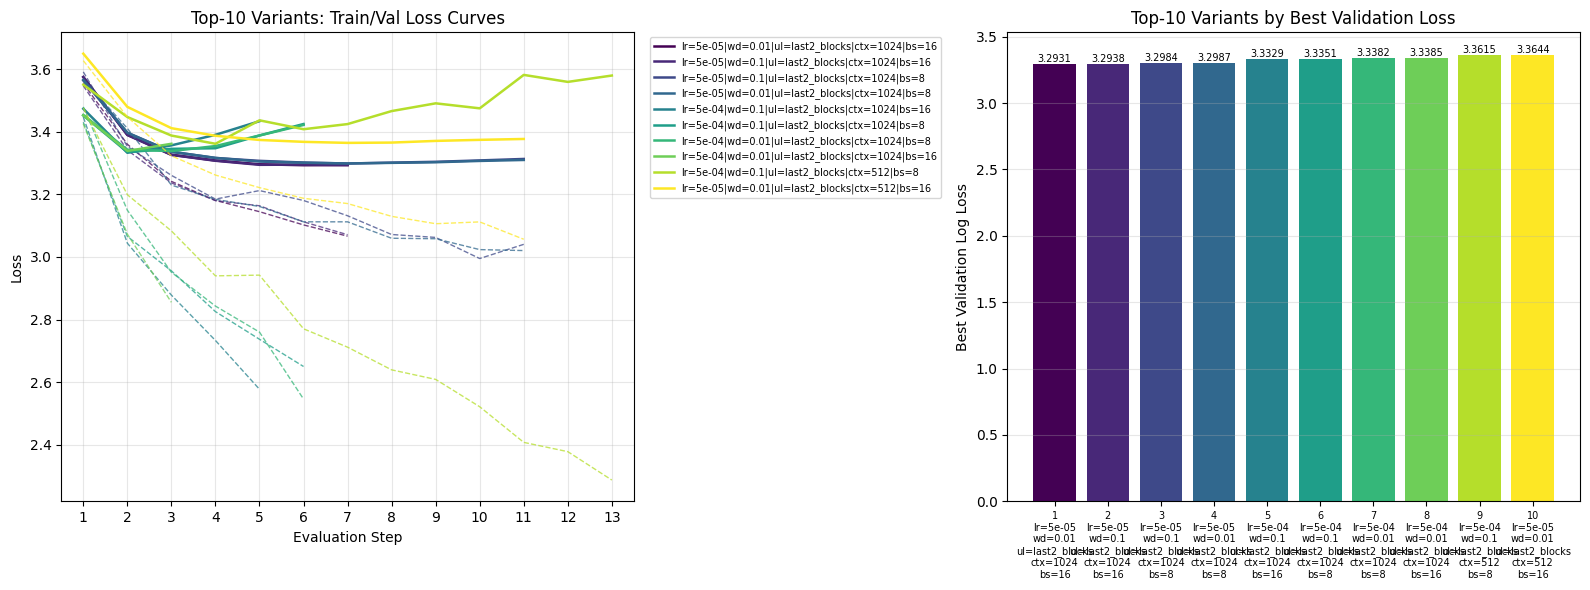

Saved: loss_comparison_top10.png


In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Keep only top-10 variants by best validation log loss
sorted_items = sorted(results_grid.items(), key=lambda kv: kv[1]["best_val_loss"])
top_k = 10
top_items = sorted_items[:top_k]
param_list_top = [k for k, _ in top_items]

# Consistent colors for top-10 variants
colors = plt.cm.viridis(np.linspace(0, 1, len(param_list_top)))
color_map = {param_list_top[i]: colors[i] for i in range(len(param_list_top))}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax_loss, ax_bar = axes

max_epochs_recorded = max(len(v["val_losses"]) for _, v in top_items)

for key, results in top_items:
    lr, wd, ul, ctx, bs = key
    color = color_map[key]

    train_losses = results["train_losses"]
    val_losses = results["val_losses"]
    x = np.arange(1, len(val_losses) + 1)

    label = f"lr={lr:.0e}|wd={wd}|ul={ul}|ctx={ctx}|bs={bs}"
    ax_loss.plot(x, train_losses, linestyle='--', linewidth=1, color=color, alpha=0.75)
    ax_loss.plot(x, val_losses, linestyle='-', linewidth=1.8, color=color, label=label)

ax_loss.set_xlabel("Evaluation Step")
ax_loss.set_ylabel("Loss")
ax_loss.set_title("Top-10 Variants: Train/Val Loss Curves")
ax_loss.set_xticks(range(1, max_epochs_recorded + 1))
ax_loss.set_xlim(1 - 0.5, max_epochs_recorded + 0.5)
ax_loss.grid(True, alpha=0.3)
ax_loss.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

# Bar plot: best validation losses for top-10 only
param_labels = [
    f"{i+1}\nlr={k[0]:.0e}\nwd={k[1]}\nul={k[2]}\nctx={k[3]}\nbs={k[4]}"
    for i, k in enumerate(param_list_top)
]
best_val_losses = [results_grid[k]["best_val_loss"] for k in param_list_top]
bar_colors = [color_map[k] for k in param_list_top]

bars = ax_bar.bar(range(len(param_list_top)), best_val_losses, color=bar_colors)
ax_bar.set_xticks(range(len(param_list_top)))
ax_bar.set_xticklabels(param_labels, fontsize=7)
ax_bar.set_ylabel("Best Validation Log Loss")
ax_bar.set_title("Top-10 Variants by Best Validation Loss")
ax_bar.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.4f}",
        ha='center',
        va='bottom',
        fontsize=7,
    )

plt.tight_layout()
plt.savefig("loss_comparison_top10.png", dpi=120, bbox_inches='tight')
plt.show()

print("Saved: loss_comparison_top10.png")

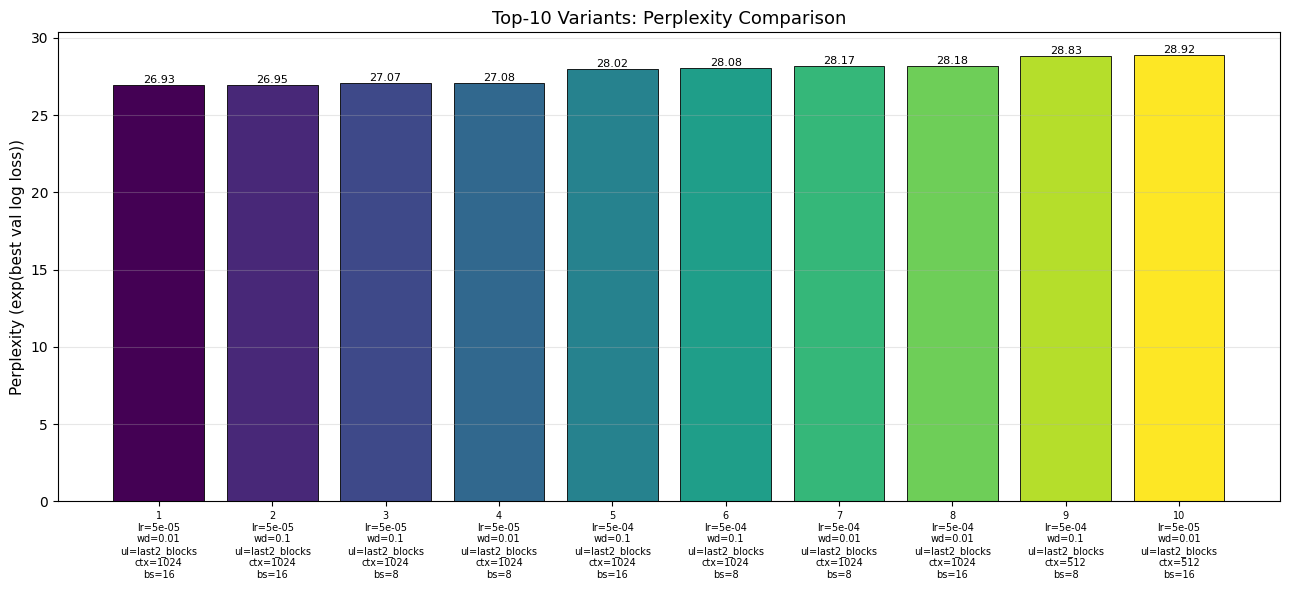


Top-10 Perplexity Comparison:
--------------------------------------------------------------------------------
#01 | lr=5e-05, wd=0.01, ul=last2_blocks, ctx=1024, bs=16 | best val loss=3.2931 | perplexity=26.93
#02 | lr=5e-05, wd=0.1, ul=last2_blocks, ctx=1024, bs=16 | best val loss=3.2938 | perplexity=26.95
#03 | lr=5e-05, wd=0.1, ul=last2_blocks, ctx=1024, bs=8 | best val loss=3.2984 | perplexity=27.07
#04 | lr=5e-05, wd=0.01, ul=last2_blocks, ctx=1024, bs=8 | best val loss=3.2987 | perplexity=27.08
#05 | lr=5e-04, wd=0.1, ul=last2_blocks, ctx=1024, bs=16 | best val loss=3.3329 | perplexity=28.02
#06 | lr=5e-04, wd=0.1, ul=last2_blocks, ctx=1024, bs=8 | best val loss=3.3351 | perplexity=28.08
#07 | lr=5e-04, wd=0.01, ul=last2_blocks, ctx=1024, bs=8 | best val loss=3.3382 | perplexity=28.17
#08 | lr=5e-04, wd=0.01, ul=last2_blocks, ctx=1024, bs=16 | best val loss=3.3385 | perplexity=28.18
#09 | lr=5e-04, wd=0.1, ul=last2_blocks, ctx=512, bs=8 | best val loss=3.3615 | perplexity=28.83

In [107]:
# Perplexity plot for top-10 variants using the same color mapping
perplexities = {}
for key, results in results_grid.items():
    # Compare perplexity derived from best validation log loss
    perplexities[key] = np.exp(results["best_val_loss"])

# Reuse top-10 ranking from best validation loss
sorted_items = sorted(results_grid.items(), key=lambda kv: kv[1]["best_val_loss"])
top_k = 10
top_items = sorted_items[:top_k]
param_list_top = [k for k, _ in top_items]

# Keep colors consistent with the loss/bar figure
colors = plt.cm.viridis(np.linspace(0, 1, len(param_list_top)))
color_map = {param_list_top[i]: colors[i] for i in range(len(param_list_top))}

fig, ax = plt.subplots(figsize=(13, 6))

param_labels = [
    f"{i+1}\nlr={k[0]:.0e}\nwd={k[1]}\nul={k[2]}\nctx={k[3]}\nbs={k[4]}"
    for i, k in enumerate(param_list_top)
]
perp_values = [perplexities[k] for k in param_list_top]
bar_colors = [color_map[k] for k in param_list_top]

bars = ax.bar(
    range(len(param_list_top)),
    perp_values,
    color=bar_colors,
    edgecolor='black',
    linewidth=0.6,
)
ax.set_xticks(range(len(param_list_top)))
ax.set_xticklabels(param_labels, fontsize=7)
ax.set_ylabel("Perplexity (exp(best val log loss))", fontsize=11)
ax.set_title("Top-10 Variants: Perplexity Comparison", fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=8,
    )

plt.tight_layout()
plt.savefig("perplexity_comparison_top10.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nTop-10 Perplexity Comparison:")
print("-" * 80)
for rank, (key, _) in enumerate(top_items, start=1):
    lr, wd, ul, ctx, bs = key
    best_loss = results_grid[key]["best_val_loss"]
    print(
        f"#{rank:02d} | lr={lr:.0e}, wd={wd}, ul={ul}, ctx={ctx}, bs={bs} "
        f"| best val loss={best_loss:.4f} | perplexity={perplexities[key]:.2f}"
    )

In [108]:
# Select the best model by smallest best validation loss
best_params = min(results_grid.items(), key=lambda x: x[1]["best_val_loss"])[0]
best_result = results_grid[best_params]

best_lr, best_wd, best_ul, best_ctx, best_bs = best_params
best_model_path = best_result["best_model_ckpt"]

print("\nBest Model Configuration:")
print(f"  Learning Rate:   {best_lr}")
print(f"  Weight Decay:    {best_wd}")
print(f"  Unfreeze Mode:   {best_ul}")
print(f"  Context Length:  {best_ctx}")
print(f"  Batch Size:      {best_bs}")
print(f"  Best Val Loss:   {best_result['best_val_loss']:.4f}")
print(f"  Perplexity:      {np.exp(best_result['best_val_loss']):.2f}")
print(f"  Checkpoint Path: {best_model_path}")

# Rebuild model with the best context length and load best checkpoint
best_model, best_cfg = build_model_from_pretrained(context_length=best_ctx)
best_model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))

best_model.to(device)
best_model.eval()

print("\n" + "=" * 60)
print("GENERATION TEST")
print("=" * 60)

torch.manual_seed(42)
start_context = "Freedom is the freedom to say that"
test_token_ids = text_to_token_ids(start_context, tokenizer).to(device)

print(f"\nStart Context: {start_context}")
print(f"Input tokens: {test_token_ids.shape}")

with torch.no_grad():
    generated_ids = generate(
        model=best_model,
        idx=test_token_ids,
        max_new_tokens=50,
        context_size=best_cfg["context_length"],
        top_k=50,
        temperature=1.0,
    )

generated_text = token_ids_to_text(generated_ids, tokenizer)
print(f"\nGenerated Text:\n{generated_text}")


Best Model Configuration:
  Learning Rate:   5e-05
  Weight Decay:    0.01
  Unfreeze Mode:   last2_blocks
  Context Length:  1024
  Batch Size:      16
  Best Val Loss:   3.2931
  Perplexity:      26.93
  Checkpoint Path: /home/docampor/usfq-mmia/logs/gpt-2/lr_5e-05_wd_0.01_ul_last2_blocks_ctx_1024_bs_16/checkpoints/best.pth

GENERATION TEST

Start Context: Freedom is the freedom to say that
Input tokens: torch.Size([1, 7])

Generated Text:
Freedom is the freedom to say that we are no longer interested in what is happening to you. When I was growing up, you were not allowed to make the sort of big political speeches that you wanted, either in class rooms or in the offices. We called it the gulag.


Looking at the top 10 parameter combinations, we see the following:
- Overall, all top 10 model variants are pretty similar both in their validation losses and perplexity.
- Unfreezing more layers was superior to just unfreezing the output head. This appears to be the hyper-parameter of highest impact.
- Something similar happens with the context length, where 8 out of 10 places were taken by the context length of 1024. Just as we expected, more appears to be better.
- For the other parameters, there doesn't seem to be a clear imbalance towards a specific value.
- Generation quality for the best performing model is very good. We tested with the phrase "Freedom is the freedom to say that" as initial context, and the results were great. We didn't get the exact phrase found in the book or something close to it, but the results are still coherent and readable for such an old model.